In [1]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import imageio
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"


# Import your local modules
# Ensure conditional_unet_depth.py and diffusion.py are in the same folder
from conditional_unet_depth import ConditionalUNetDepth
from diffusion import GaussianDiffusion, DiffusionConfig

# --- Configuration ---
CONFIG = {
    "img_size": 128,        # Resize all images to this (e.g., 128 or 256)
    "batch_size": 16,       # Adjust based on VRAM (8GB should handle 16-32 at 128x128)
    "lr": 1e-4,
    "epochs": 25,
    "timesteps": 1000,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    # Paths are relative to the term_project folder
    "synthetic_root": "../dataset/synthetic_dataset",
    # Use both d415_dataset and d435_dataset under real-val
    "real_val_root": "../dataset/real-val",
}

print(f"Running on device: {CONFIG['device']}")


Running on device: cuda


In [2]:

# --- Dataset Class ---

class ClearGraspDataset(Dataset):
    def __init__(self, root_dir, split="synthetic", img_size=128, max_depth=3.0):
        """
        Args:
            root_dir: Path to dataset folder.
            split: "synthetic" (training) or "real" (validation/test).
            img_size: Target size for resizing (square).
            max_depth: Maximum depth value (in meters) for normalization.
                       ClearGrasp usually clips around 3m-10m. 3.0m is a safe focus for manipulation.
        """
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.max_depth = max_depth

        self.samples = []

        if self.split == "synthetic":
            # Synthetic structure: Class/depth-imgs-rectified/*.exr
            # We need to find matching RGB and Mask files.
            # Assumes structure: class_name/depth-imgs-rectified/000.exr
            #                    class_name/rgb-imgs/000.jpg
            #                    class_name/segmentation-masks/000.png (or similar)

            # Walk through all class folders
            for class_folder in glob.glob(os.path.join(root_dir, "*")):
                if not os.path.isdir(class_folder): continue

                depth_folder = os.path.join(class_folder, "depth-imgs-rectified")
                rgb_folder = os.path.join(class_folder, "rgb-imgs")
                # Note: Check the exact name of your mask folder in the synthetic dataset!
                # Often it is 'segmentation-masks' or similar.
                mask_folder = os.path.join(class_folder, "segmentation-masks")

                if not os.path.exists(depth_folder): continue

                depth_files = sorted(glob.glob(os.path.join(depth_folder, "*.exr")))

                for df in depth_files:
                    basename = os.path.basename(df).split("-")[0] # e.g. "000000000"

                    # Construct paths for RGB and Mask
                    # Adjust extensions/naming patterns based on your actual file listing!
                    rgb_path = os.path.join(rgb_folder, f"{basename}-rgb.jpg")
                    mask_path = os.path.join(mask_folder, f"{basename}-segmentation-mask.png")

                    if os.path.exists(rgb_path) and os.path.exists(mask_path):
                        self.samples.append({
                            "depth": df,
                            "rgb": rgb_path,
                            "mask": mask_path
                        })

        elif self.split == "real":
            # Real Val/Test structure (flat folder):
            # 000-opaque-depth-img.exr (Target)
            # 000-transparent-depth-img.exr (Input Bad Depth)
            # 000-transparent-rgb-img.jpg (Input RGB)

            # We iterate over opaque depth (ground truth targets)
            target_files = sorted(glob.glob(os.path.join(root_dir, "**", "*-opaque-depth-img.exr"), recursive=True))

            for tf in target_files:
                # e.g. .../000000000-opaque-depth-img.exr
                prefix = tf.split("-opaque")[0] # .../000000000

                input_depth_path = f"{prefix}-transparent-depth-img.exr"
                input_rgb_path = f"{prefix}-transparent-rgb-img.jpg"

                if os.path.exists(input_depth_path) and os.path.exists(input_rgb_path):
                    self.samples.append({
                        "target_depth": tf,
                        "input_depth": input_depth_path,
                        "rgb": input_rgb_path
                    })

        print(f"Found {len(self.samples)} samples for split: {split}")

    def load_exr(self, path):
        # Load EXR file using OpenCV
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise RuntimeError(f"Failed to load EXR: {path}")
        # Handle potential multi-channel EXR (take first channel if 3)
        if len(img.shape) == 3:
            img = img[:, :, 0]
        img = img.astype(np.float32)
        # Replace NaN / Inf with 0 (background)
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        return img

    def process_image(self, img, is_depth=False):
        # 1. Center Crop to square
        h, w = img.shape[:2]
        min_dim = min(h, w)
        top = (h - min_dim) // 2
        left = (w - min_dim) // 2
        img = img[top:top+min_dim, left:left+min_dim]

        # 2. Resize
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST if is_depth else cv2.INTER_LINEAR)

        # 3. To Tensor
        if not is_depth:
            # RGB: (H, W, 3) -> (3, H, W), scale 0-255 to [-1, 1]
            img = torch.from_numpy(img).permute(2, 0, 1).float()
            img = (img / 127.5) - 1.0
        else:
            # Depth: (H, W) -> (1, H, W)
            img = torch.from_numpy(img).unsqueeze(0).float()
            # Normalize depth: [0, max_depth] -> [-1, 1]
            # Clip to max depth first
            img = torch.clamp(img, 0, self.max_depth)
            # Scale to [0, 1]
            img = img / self.max_depth
            # Scale to [-1, 1] for diffusion
            img = (img * 2.0) - 1.0

        return img

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # --- Load RGB ---
        rgb = cv2.imread(sample["rgb"])
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB) # OpenCV loads BGR
        rgb_tensor = self.process_image(rgb, is_depth=False)

        if self.split == "synthetic":
            # --- Synthetic: Create Corruption ---
            target_depth_raw = self.load_exr(sample["depth"])

            # Load Mask (0=Background, 255=Object)
            # Mask filenames might need adjustment based on exact dataset names
            mask = cv2.imread(sample["mask"], cv2.IMREAD_GRAYSCALE)

            # Ensure mask and depth match size (sometimes synthetic data has mismatches)
            if mask.shape != target_depth_raw.shape:
                mask = cv2.resize(mask, (target_depth_raw.shape[1], target_depth_raw.shape[0]), interpolation=cv2.INTER_NEAREST)

            # Process Target (Perfect) Depth
            target_depth_tensor = self.process_image(target_depth_raw, is_depth=True)

            # Create Input (Corrupted) Depth
            # Important: Crop/Resize mask SAME as depth
            mask_tensor = self.process_image(mask, is_depth=True) # reusing depth logic for single channel
            # mask_tensor is [-1, 1] now due to process_image logic for depth.
            # Let's fix logic: > 0 means transparent object.
            # Since mask was 0 or 255, normalized it becomes -1 or 1 approx.

            input_depth_tensor = target_depth_tensor.clone()
            # Corruption: Set pixels where mask indicates object to "empty" (-1.0 in our normalized space)
            input_depth_tensor[mask_tensor > 0.0] = -1.0

        else:
            # --- Real: Load existing pair ---
            target_depth_raw = self.load_exr(sample["target_depth"])
            input_depth_raw = self.load_exr(sample["input_depth"])

            target_depth_tensor = self.process_image(target_depth_raw, is_depth=True)
            input_depth_tensor = self.process_image(input_depth_raw, is_depth=True)

        # Conditioning = RGB (3) + Input Bad Depth (1)
        conditioning = torch.cat([rgb_tensor, input_depth_tensor], dim=0)

        return {
            "pixel_values": target_depth_tensor, # What we want to predict (x0)
            "conditioning": conditioning         # What we know
        }

    def __len__(self):
        return len(self.samples)


Found 263 samples for split: real
RGBD Cond Shape: torch.Size([4, 128, 128])
Target Depth Shape: torch.Size([1, 128, 128])
Depth Range: -1.0 -0.2337239384651184


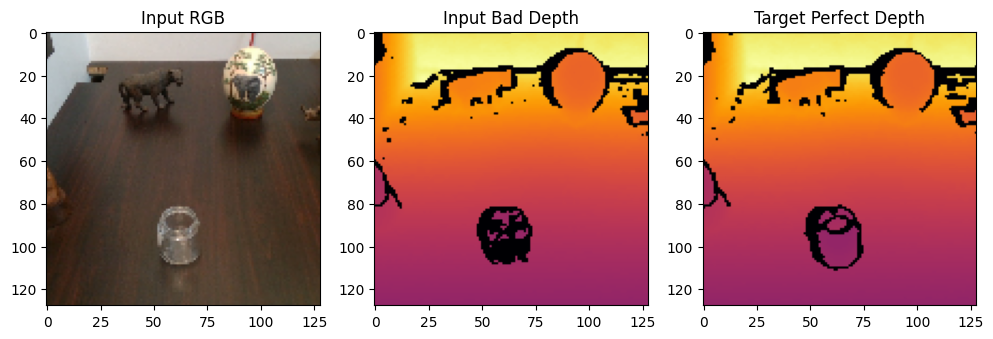

In [3]:

# --- Sanity Check Block ---
if __name__ == "__main__":
    # Create dummy datasets (assuming you have pointed paths correctly)
    # If you don't have data yet, this will just print 0 samples
    try:
        ds = ClearGraspDataset(CONFIG['real_val_root'], split="real", img_size=128)
        if len(ds) > 0:
            item = ds[0]
            print("RGBD Cond Shape:", item["conditioning"].shape)
            print("Target Depth Shape:", item["pixel_values"].shape)
            print("Depth Range:", item["pixel_values"].min().item(), item["pixel_values"].max().item())

            # Visualization
            cond_img = item["conditioning"][:3].permute(1, 2, 0).cpu().numpy() # RGB
            cond_img = (cond_img + 1) / 2.0 # to [0, 1]

            bad_depth = item["conditioning"][3].cpu().numpy()
            good_depth = item["pixel_values"][0].cpu().numpy()

            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(cond_img)
            ax[0].set_title("Input RGB")
            ax[1].imshow(bad_depth, cmap='inferno')
            ax[1].set_title("Input Bad Depth")
            ax[2].imshow(good_depth, cmap='inferno')
            ax[2].set_title("Target Perfect Depth")
            plt.show()
    except Exception as e:
        print(f"Could not load dataset for sanity check: {e}")
        print("Please verify paths in CONFIG")

In [4]:
def train():
    # 1. Setup Model & Diffusion
    model = ConditionalUNetDepth().to(CONFIG["device"])
    diffusion = GaussianDiffusion(model=model, config=DiffusionConfig(timesteps=CONFIG["timesteps"])).to(CONFIG["device"])

    # 2. Setup Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"])

    # 3. Setup Dataloader
    # We focus on synthetic data for training as per plan
    train_ds = ClearGraspDataset(CONFIG['synthetic_root'], split="synthetic", img_size=CONFIG['img_size'])
    train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=True)

    # Validation set (Real data) for periodic sampling
    val_ds = ClearGraspDataset(CONFIG['real_val_root'], split="real", img_size=CONFIG['img_size'])
    # Fixed batch for consistent visualization
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=True)
    val_batch = next(iter(val_loader))
    val_cond = val_batch["conditioning"].to(CONFIG["device"])
    val_gt = val_batch["pixel_values"].to(CONFIG["device"])

    print(f"Starting training on {len(train_ds)} samples...")

    # 4. Training Loop
    for epoch in range(CONFIG["epochs"]):
        model.train()
        epoch_loss = 0

        for step, batch in enumerate(train_dl):
            optimizer.zero_grad()

            # Move batch to device
            batch_device = {
                "pixel_values": batch["pixel_values"].to(CONFIG["device"]),
                "conditioning": batch["conditioning"].to(CONFIG["device"])
            }

            # Calculate Loss
            loss = diffusion.p_losses(batch_device)

            # Backprop
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if step % 100 == 0:
                print(f"Epoch {epoch} | Step {step} | Loss: {loss.item():.4f}")

        avg_loss = epoch_loss / len(train_dl)
        print(f"Epoch {epoch} Completed. Avg Loss: {avg_loss:.4f}")

        # 5. Periodic Sampling (Validation)
        if epoch % 5 == 0: # Sample every 5 epochs
            print("Sampling validation images...")
            model.eval()
            with torch.no_grad():
                # Generate depth from the real-world "bad" depth
                sampled_depth = diffusion.sample(cond=val_cond, shape=(4, 1, CONFIG['img_size'], CONFIG['img_size']))

                # Visualize first sample in batch
                # RGB
                rgb_viz = (val_cond[0, :3].permute(1, 2, 0).cpu().numpy() + 1) / 2
                # Bad Input Depth
                input_depth_viz = (val_cond[0, 3].cpu().numpy() + 1) / 2
                # Generated Depth
                gen_depth_viz = (sampled_depth[0, 0].cpu().numpy() + 1) / 2
                # Ground Truth
                gt_depth_viz = (val_gt[0, 0].cpu().numpy() + 1) / 2

                fig, ax = plt.subplots(1, 4, figsize=(20, 5))
                ax[0].imshow(np.clip(rgb_viz, 0, 1))
                ax[0].set_title("Input RGB")
                ax[1].imshow(input_depth_viz, cmap='inferno')
                ax[1].set_title("Input Bad Depth")
                ax[2].imshow(gen_depth_viz, cmap='inferno')
                ax[2].set_title(f"Generated (Epoch {epoch})")
                ax[3].imshow(gt_depth_viz, cmap='inferno')
                ax[3].set_title("Ground Truth")
                plt.show()

            # Save Checkpoint
            torch.save(model.state_dict(), f"model_epoch_{epoch}.pt")

Found 940 samples for split: synthetic
Found 263 samples for split: real
Starting training on 940 samples...
Epoch 0 | Step 0 | Loss: 1.0938
Epoch 0 | Step 0 | Loss: 1.0938
Epoch 0 Completed. Avg Loss: 0.1728
Sampling validation images...
Epoch 0 Completed. Avg Loss: 0.1728
Sampling validation images...


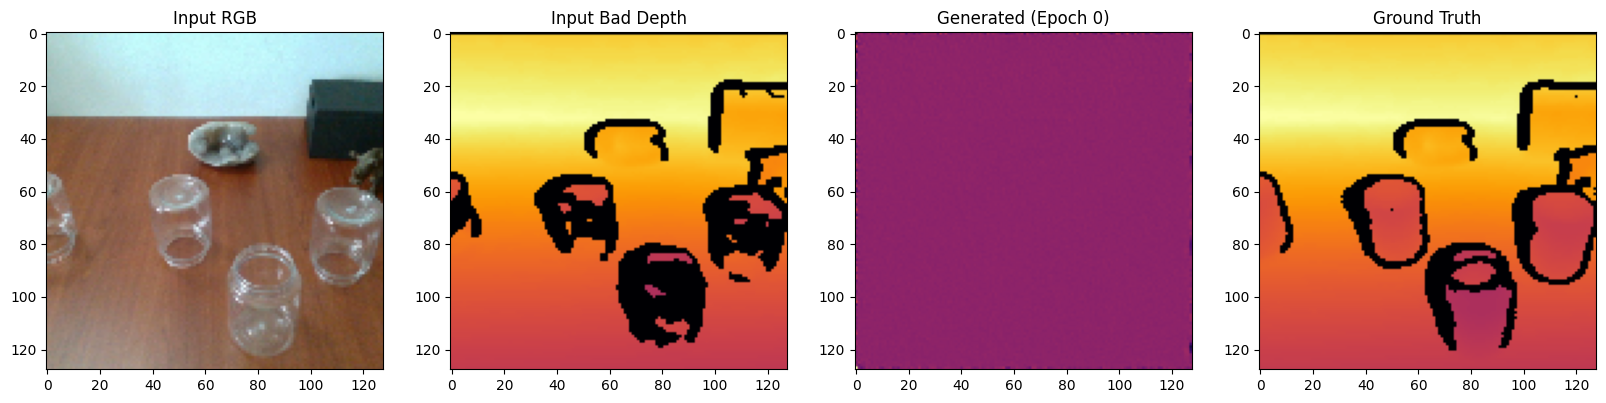

Epoch 1 | Step 0 | Loss: 0.0833
Epoch 1 Completed. Avg Loss: 0.0397
Epoch 1 Completed. Avg Loss: 0.0397
Epoch 2 | Step 0 | Loss: 0.0194
Epoch 2 | Step 0 | Loss: 0.0194
Epoch 2 Completed. Avg Loss: 0.0239
Epoch 2 Completed. Avg Loss: 0.0239
Epoch 3 | Step 0 | Loss: 0.0190
Epoch 3 | Step 0 | Loss: 0.0190
Epoch 3 Completed. Avg Loss: 0.0197
Epoch 3 Completed. Avg Loss: 0.0197
Epoch 4 | Step 0 | Loss: 0.0161
Epoch 4 | Step 0 | Loss: 0.0161
Epoch 4 Completed. Avg Loss: 0.0163
Epoch 4 Completed. Avg Loss: 0.0163
Epoch 5 | Step 0 | Loss: 0.0107
Epoch 5 | Step 0 | Loss: 0.0107
Epoch 5 Completed. Avg Loss: 0.0138
Sampling validation images...
Epoch 5 Completed. Avg Loss: 0.0138
Sampling validation images...


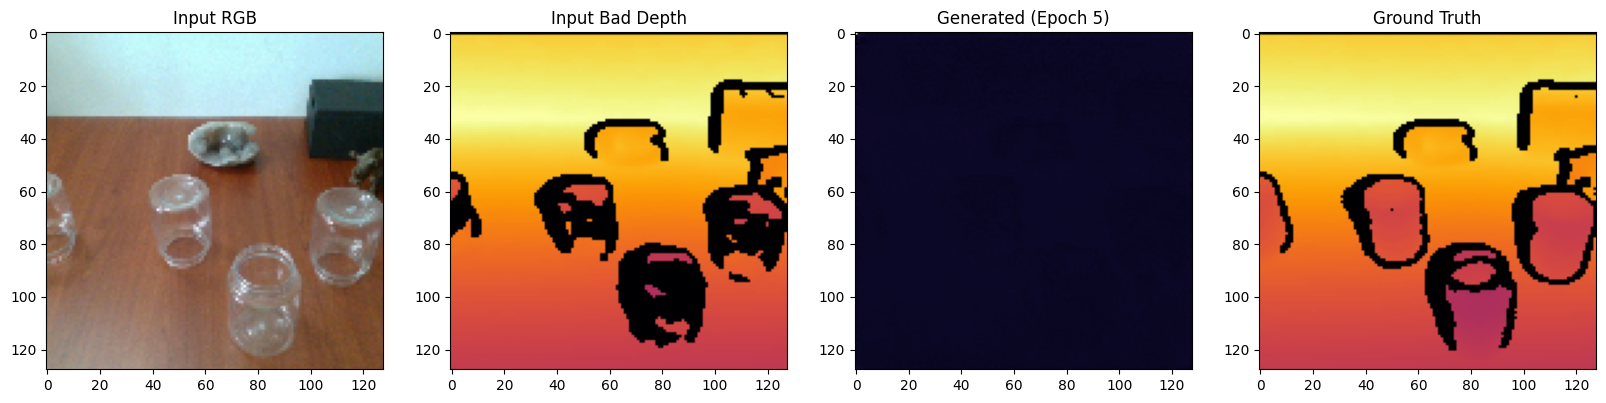

Epoch 6 | Step 0 | Loss: 0.0681
Epoch 6 Completed. Avg Loss: 0.0121
Epoch 6 Completed. Avg Loss: 0.0121
Epoch 7 | Step 0 | Loss: 0.0056
Epoch 7 | Step 0 | Loss: 0.0056
Epoch 7 Completed. Avg Loss: 0.0101
Epoch 7 Completed. Avg Loss: 0.0101
Epoch 8 | Step 0 | Loss: 0.0050
Epoch 8 | Step 0 | Loss: 0.0050
Epoch 8 Completed. Avg Loss: 0.0066
Epoch 8 Completed. Avg Loss: 0.0066
Epoch 9 | Step 0 | Loss: 0.0029
Epoch 9 | Step 0 | Loss: 0.0029
Epoch 9 Completed. Avg Loss: 0.0077
Epoch 9 Completed. Avg Loss: 0.0077
Epoch 10 | Step 0 | Loss: 0.0030
Epoch 10 | Step 0 | Loss: 0.0030
Epoch 10 Completed. Avg Loss: 0.0069
Sampling validation images...
Epoch 10 Completed. Avg Loss: 0.0069
Sampling validation images...


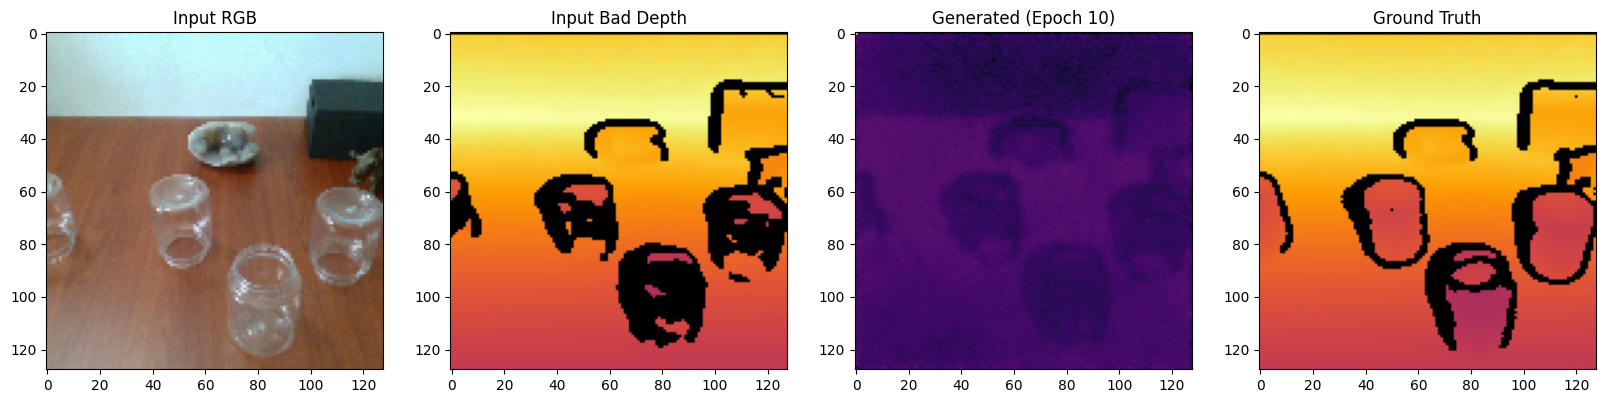

Epoch 11 | Step 0 | Loss: 0.0040
Epoch 11 Completed. Avg Loss: 0.0055
Epoch 11 Completed. Avg Loss: 0.0055
Epoch 12 | Step 0 | Loss: 0.0026
Epoch 12 | Step 0 | Loss: 0.0026
Epoch 12 Completed. Avg Loss: 0.0066
Epoch 12 Completed. Avg Loss: 0.0066
Epoch 13 | Step 0 | Loss: 0.0064
Epoch 13 | Step 0 | Loss: 0.0064
Epoch 13 Completed. Avg Loss: 0.0060
Epoch 13 Completed. Avg Loss: 0.0060
Epoch 14 | Step 0 | Loss: 0.0026
Epoch 14 | Step 0 | Loss: 0.0026
Epoch 14 Completed. Avg Loss: 0.0047
Epoch 14 Completed. Avg Loss: 0.0047
Epoch 15 | Step 0 | Loss: 0.0018
Epoch 15 | Step 0 | Loss: 0.0018
Epoch 15 Completed. Avg Loss: 0.0042
Sampling validation images...
Epoch 15 Completed. Avg Loss: 0.0042
Sampling validation images...


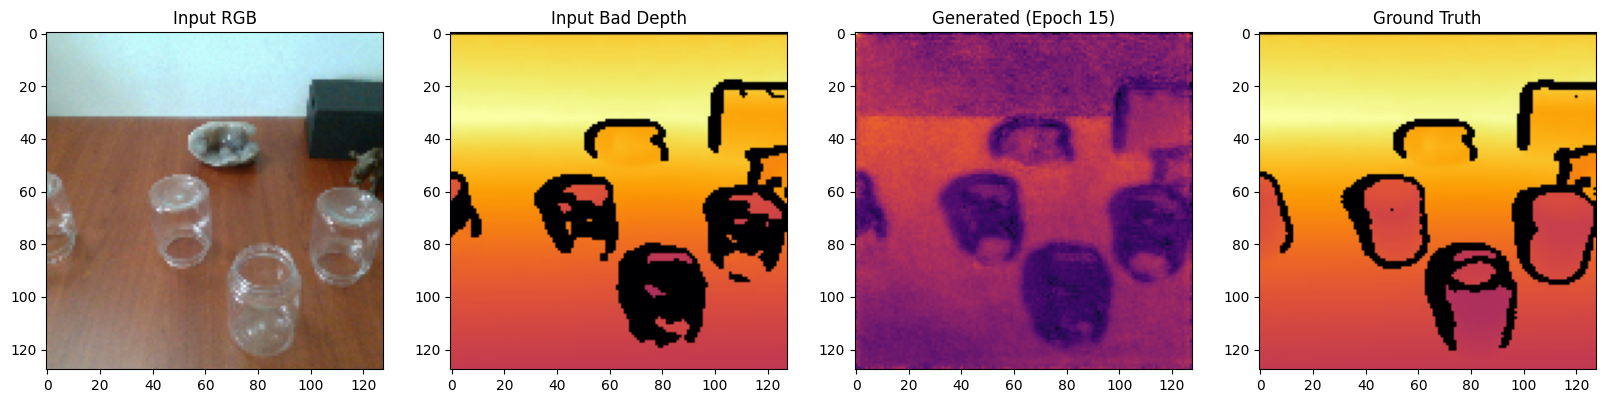

Epoch 16 | Step 0 | Loss: 0.0028
Epoch 16 Completed. Avg Loss: 0.0039
Epoch 16 Completed. Avg Loss: 0.0039
Epoch 17 | Step 0 | Loss: 0.0025
Epoch 17 | Step 0 | Loss: 0.0025
Epoch 17 Completed. Avg Loss: 0.0037
Epoch 17 Completed. Avg Loss: 0.0037
Epoch 18 | Step 0 | Loss: 0.0019
Epoch 18 | Step 0 | Loss: 0.0019
Epoch 18 Completed. Avg Loss: 0.0036
Epoch 18 Completed. Avg Loss: 0.0036
Epoch 19 | Step 0 | Loss: 0.0017
Epoch 19 | Step 0 | Loss: 0.0017
Epoch 19 Completed. Avg Loss: 0.0035
Epoch 19 Completed. Avg Loss: 0.0035
Epoch 20 | Step 0 | Loss: 0.0020
Epoch 20 | Step 0 | Loss: 0.0020
Epoch 20 Completed. Avg Loss: 0.0029
Sampling validation images...
Epoch 20 Completed. Avg Loss: 0.0029
Sampling validation images...


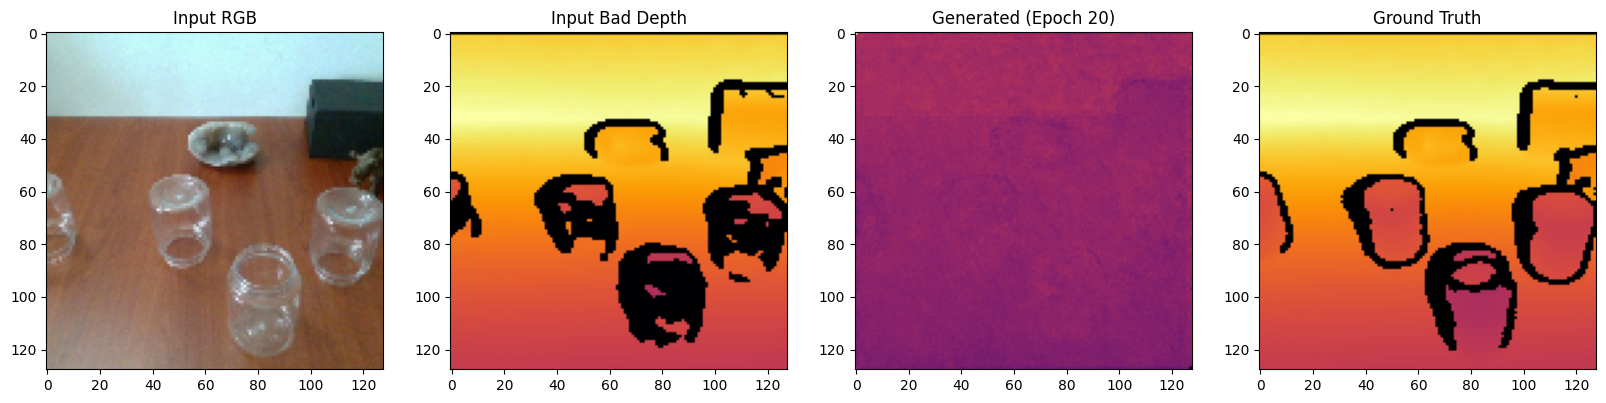

Epoch 21 | Step 0 | Loss: 0.0009
Epoch 21 Completed. Avg Loss: 0.0022
Epoch 21 Completed. Avg Loss: 0.0022
Epoch 22 | Step 0 | Loss: 0.0051
Epoch 22 | Step 0 | Loss: 0.0051
Epoch 22 Completed. Avg Loss: 0.0026
Epoch 22 Completed. Avg Loss: 0.0026
Epoch 23 | Step 0 | Loss: 0.0018
Epoch 23 | Step 0 | Loss: 0.0018
Epoch 23 Completed. Avg Loss: 0.0031
Epoch 23 Completed. Avg Loss: 0.0031
Epoch 24 | Step 0 | Loss: 0.0018
Epoch 24 | Step 0 | Loss: 0.0018
Epoch 24 Completed. Avg Loss: 0.0033
Epoch 24 Completed. Avg Loss: 0.0033


In [5]:
if __name__ == "__main__":
    train()